In [51]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import os
import sklearn as sk
import scipy as sp
import seaborn as sns
import kneed as kn
#import pickle
#from scipy.spatial import cKDTree
#from SCTransform import SCTransform

# if you installed the nico package 
#import nico
#from nico import Annotations as sann
    
# if you did not install the nico package and downloaded the nico files into the current directory
# import Annotations as sann


import warnings
from collections import namedtuple
from typing import NamedTuple, Callable
import time
warnings.filterwarnings('ignore')
from scipy.stats import pearsonr, spearmanr
from ridgeplot import ridgeplot
#export PYTHONWARNINGS='ignore:Multiprocessing-backed parallel loops:UserWarning'
#os.environ["PYTHONWARNINGS"] = "ignore::UserWarning"


In [52]:
filter_by_obs_value = lambda adata, obs_column, obs_value: adata[adata.obs[obs_column] == obs_value].copy()

In [53]:
# This is input data path for the scRNA-seq and spatial data 
# If the data is not in h5ad or csv format then please adjust following the standard scanpy routine. 

scdatapath='./data/inputRef/'
spdatapath='./data/inputQuery/'

ad_sp=sc.read(spdatapath+'gene_by_cell.csv').transpose()
ad=sc.read_h5ad(scdatapath+'input_ref.h5ad') 

# This is the coordinate file of the cell centroids from the spatial transcriptomics experiment.  
coordinate = pd.read_csv(spdatapath+'tissue_positions_list.csv')
coordinate=coordinate.to_numpy()

In [54]:
ad_sp_a=sc.read_h5ad('./data/nico_out/nico_celltype_annotation.h5ad') 

In [55]:
ad_sp.obs["nico_ct"] = ad_sp_a.obs["nico_ct"]
ad_sp.obs

,nico_ct
cell1,Lymphatic
cell2,Lymphatic
cell3,Lymphatic
cell4,Lymphatic
cell5,Lymphatic
...,...
cell8165,BZE
cell8166,Lymphatic
cell8167,Lymphatic
cell8176,Lymphatic


In [56]:

adr=ad[ad.obs['cluster'] == "Stem/TA"]
sc.pp.filter_genes(adr, min_counts=1)
sc.pp.normalize_total(adr)
sc.pp.log1p(adr)

sc.tl.pca(adr)
sc.pp.neighbors(adr)
sc.tl.leiden(adr)
sc.tl.umap(adr)
df=adr.X.transpose()

In [57]:
shared_genes_mask_sp=np.isin(adr.var.index.to_list(),ad_sp.var.index.to_list()) 
shared_genes_mask=np.isin(adr.var.index.to_list(),adr.var.index.to_list())
H = sk.decomposition.non_negative_factorization(adr[:, shared_genes_mask].X, n_components=3)[1]
mask=np.isin(adr.var.index.to_list(),ad_sp.var.index.to_list())
genes=adr.var.index[mask].to_list()
spr=ad_sp[ad_sp_a.obs['nico_ct'] == 'Stem/TA',genes]

In [58]:
ad_sp_stem = filter_by_obs_value(ad_sp, "nico_ct", "Stem/TA")

In [59]:
class Result(NamedTuple):
    original_counts: np.ndarray
    predicted_counts: np.ndarray

def predict_genes(
    adata_query: sc.AnnData,
    H: np.ndarray, 
    subidx: np.ndarray,
    compidx: np.ndarray,
    genes: list
) -> Result:

    shared_genes_indexer = adata_query.var_names.get_indexer_for(genes)
    w = sk.decomposition.non_negative_factorization(
        adata_query[:, shared_genes_indexer][:, subidx].X,
        H=H[:, shared_genes_mask_sp][:, subidx],
        init="custom", 
        update_H=False
    )[0]

    return Result(
        adata_query[:, shared_genes_indexer][:, compidx].X,
        w @ H[:, shared_genes_mask_sp][:, compidx]
    )

In [60]:
gene_samples = [(lambda arr, n: (arr[:n], arr[n:]))(
    np.random.permutation(np.arange(np.sum(shared_genes_mask_sp))),
    100
) for _ in range(1000)]
data = [predict_genes(ad_sp_stem, H, subidx, compidx, genes) for subidx, compidx in gene_samples]

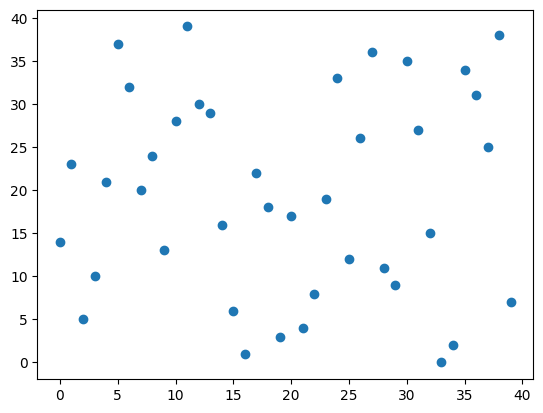

In [81]:
plt.scatter(
    data[0].predicted_counts.mean(axis=0).argsort(),
    data[0].original_counts.mean(axis=0).argsort(),
)

In [101]:
np.random.normal(0, 1, 20)

array([-0.94800624, -0.90244238,  0.0915869 ,  1.40139148,  0.74717688,
        0.88835944,  0.03266736, -0.129569  , -0.60963048, -1.24408705,
       -0.55137519,  1.92481611,  0.37281305, -0.68723978,  0.43928476,
        0.01451487,  1.12271386, -0.75138085, -0.30206314, -0.25868416])

In [147]:
x = np.random.choice(100, 10000)
y = x + np.random.normal(0, 30, 10000)
spearmanr(x, y)

SignificanceResult(statistic=np.float64(0.6970158927337566), pvalue=np.float64(0.0))

In [112]:
spearmanr(x, y)

SignificanceResult(statistic=np.float64(0.9526029787106371), pvalue=np.float64(0.0))

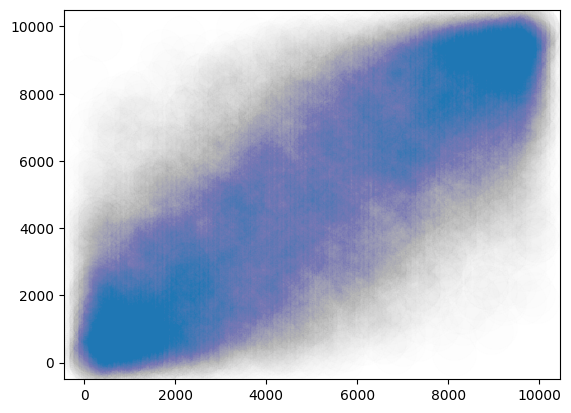

In [148]:
from scipy.stats import rankdata
plt.scatter(
    rankdata(x),
    rankdata(y),
    s=1000,
    alpha=0.003
)

array([15,  7, 33, 31, 29, 13, 39, 11, 36,  9, 20, 22, 10, 17, 27,  0, 24,
       14, 32, 28,  6,  8, 38,  3, 16,  1, 25, 37, 12, 19, 23,  5,  2, 30,
       35, 34, 18, 26, 21,  4])

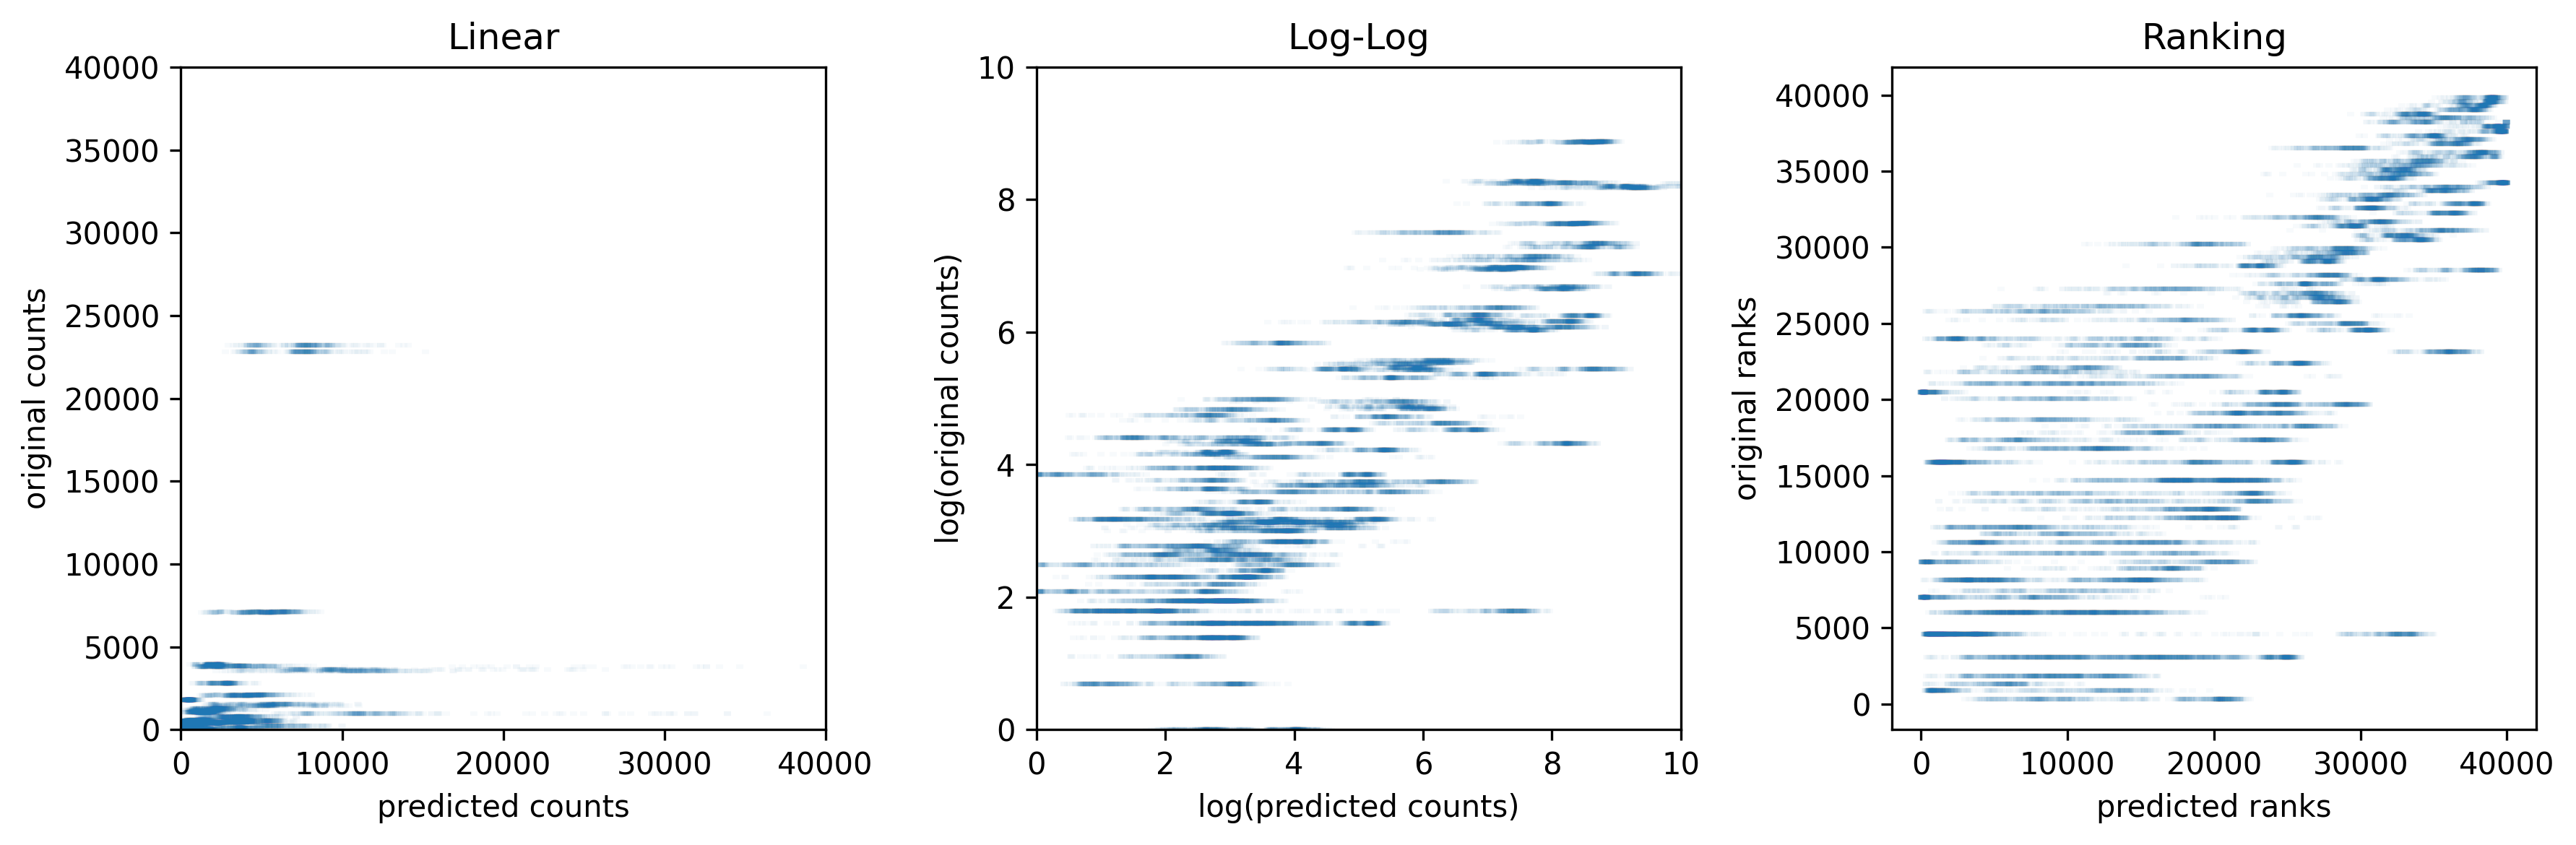

In [171]:
x, y = (lambda arr: (arr[0], arr[1]))(
    np.hstack([np.vstack([result.predicted_counts.sum(axis=0), result.original_counts.sum(axis=0)]) for result in data])
)
fig, axes = plt.subplots(1, 3, figsize=(12, 4), dpi=300)  

axes[0].scatter(x, y, s=5, marker="_", alpha=0.03)
axes[0].set_title("Linear")
axes[0].set_xlabel("predicted counts")
axes[0].set_ylabel("original counts")
axes[0].set_ylim(0, 40000)
axes[0].set_xlim(0, 40000)

axes[1].scatter(np.log(x + 1), np.log(y + 1), s=5, marker="_", alpha=0.03)
axes[1].set_title("Log-Log")
axes[1].set_xlabel("log(predicted counts)")
axes[1].set_ylabel("log(original counts)")
axes[1].set_ylim(0, 10)
axes[1].set_xlim(0, 10)

axes[2].scatter(rankdata(x), rankdata(y), s=5, marker="_", alpha=0.03)
axes[2].set_title("Ranking")
axes[2].set_xlabel("predicted ranks")
axes[2].set_ylabel("original ranks")
#axes[2].set_ylim(0, 40000)
#axes[2].set_xlim(0, 40000)

plt.tight_layout()
plt.show()

In [62]:
def transform_return_value(func, transform_fn):
    def wrapper(*args, **kwargs):
        result = func(*args, **kwargs)
        transformed_result = transform_fn(result)
        return transformed_result
    return wrapper

raw_correlation = lambda func: lambda result: func(result.original_counts.mean(axis=0), result.predicted_counts.mean(axis=0))
transform_correlation = lambda func: lambda result: func(np.log(result.original_counts.mean(axis=0) + 1e-3), np.log(result.predicted_counts.mean(axis=0) + 1e-3))

In [63]:
from scipy.stats import pearsonr, spearmanr
from scipy.spatial.distance import cosine

def raw_correlation(correlation_func):
    def compute_correlation(result):
        return correlation_func(
            result.original_counts.mean(axis=0),
            result.predicted_counts.mean(axis=0),
        )
    return compute_correlation

def transform_correlation(correlation_func):
    def compute_correlation(result):
        return correlation_func(
            np.log(result.original_counts.mean(axis=0) + 1e-3),
            np.log(result.predicted_counts.mean(axis=0) + 1e-3),
        )
    return compute_correlation

raw_correlation(pearsonr)
transform_correlation(pearsonr)

raw_correlation(spearmanr)
transform_correlation(spearmanr)

raw_correlation(cosine)
transform_correlation(cosine)

<function __main__.transform_correlation.<locals>.compute_correlation(result)>

In [64]:
original_counts = data[0].original_counts
predicted_counts = data[0].predicted_counts
pearsonr(
    original_counts.mean(axis=0),
    predicted_counts.mean(axis=0)
)

PearsonRResult(statistic=np.float32(0.8200668), pvalue=np.float64(9.527361809704279e-11))

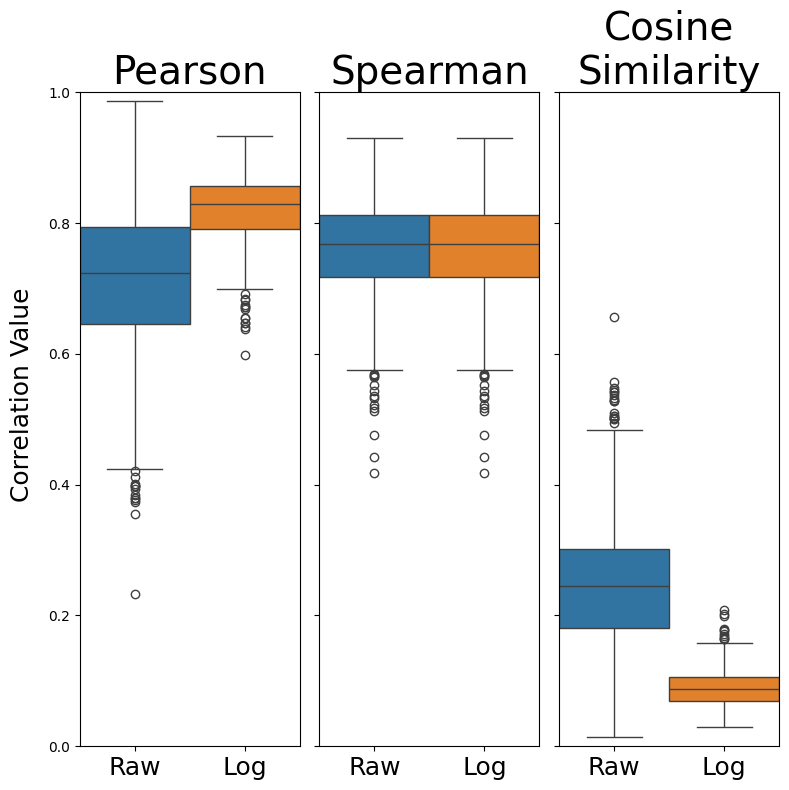

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(8, 8), dpi=100, sharey=True)

sns.boxplot(
    ax=axes[0],
    data=[
        list(map(raw_correlation(transform_return_value(pearsonr, lambda x: float(x[0]))), data)),
        list(map(transform_correlation(transform_return_value(pearsonr, lambda x: float(x[0]))), data)),
    ],
    width=1
)
axes[0].set_title("Pearson", fontsize=28)
axes[0].set_ylim(0, 1)
axes[0].set_xticklabels(["Raw", "Log"], fontsize=18)

sns.boxplot(
    ax=axes[1],
    data=[
        list(map(raw_correlation(transform_return_value(spearmanr, lambda x: float(x[0]))), data)),
        list(map(transform_correlation(transform_return_value(spearmanr, lambda x: float(x[0]))), data)),
    ],
    width=1
)
axes[1].set_title("Spearman", fontsize=28)
axes[1].set_xticklabels(["Raw", "Log"], fontsize=18)

sns.boxplot(
    ax=axes[2],
    data=[
        list(map(raw_correlation(transform_return_value(sp.spatial.distance.cosine, lambda x: float(x))), data)),
        list(map(transform_correlation(transform_return_value(sp.spatial.distance.cosine, lambda x: float(x))), data)),
    ],
    width=1
)
axes[2].set_title("Cosine\nSimilarity", fontsize=28)
axes[2].set_xticklabels(["Raw", "Log"], fontsize=18)

fig.supylabel("Correlation Value", fontsize=18)

plt.tight_layout()
plt.show()

In [66]:
def batch_correlation(
        datas: list[list[Result]], 
        correlation_func: Callable[[Result], float]
) -> np.ndarray:
    """
    Computes correlation values for a batch of datasets using the given correlation function.

    Args:
        datas (list[list[Result]]): A list of datasets, each containing multiple Result objects.
        correlation_func (Callable[[Result], float]): A function that computes a correlation from a Result.

    Returns:
        np.ndarray: A transposed 2D array of computed correlation values.
    """
    return np.array([
        np.array([
            correlation_func(d)
            for d in data
        ], dtype=float)
        for data in datas
    ], dtype=float).T

In [67]:
datas = []
n_components_range = [2, 3, 4, 5, 6, 7, 8, 9, 10]
for n_components in n_components_range:
    H = sk.decomposition.non_negative_factorization(adr[:, shared_genes_mask].X, n_components=n_components)[1]
    datas.append([predict_genes(ad_sp_stem, H, subidx, compidx, genes) for subidx, compidx in gene_samples])

In [68]:
pearson_raw = pd.DataFrame(
    batch_correlation(
        datas,
        raw_correlation(transform_return_value(pearsonr, lambda x: float(x[0])))
    ),
    columns=n_components_range
)

pearson_transform = pd.DataFrame(
    batch_correlation(
        datas,
        transform_correlation(transform_return_value(pearsonr, lambda x: float(x[0])))
    ),
    columns=n_components_range
)

spearman_raw = pd.DataFrame(
    batch_correlation(
        datas,
        raw_correlation(transform_return_value(spearmanr, lambda x: float(x[0])))
    ),
    columns=n_components_range
)
spearman_transform = pd.DataFrame(
    batch_correlation(
        datas,
        transform_correlation(transform_return_value(spearmanr, lambda x: float(x[0])))
    ),
    columns=n_components_range
)

cosine_raw = pd.DataFrame(
    batch_correlation(
        datas,
        raw_correlation(transform_return_value(cosine, lambda x: float(x)))
    ),
    columns=n_components_range
)
cosine_transform = pd.DataFrame(
    batch_correlation(
        datas,
        transform_correlation(transform_return_value(cosine, lambda x: float(x)))
    ),
    columns=n_components_range
)




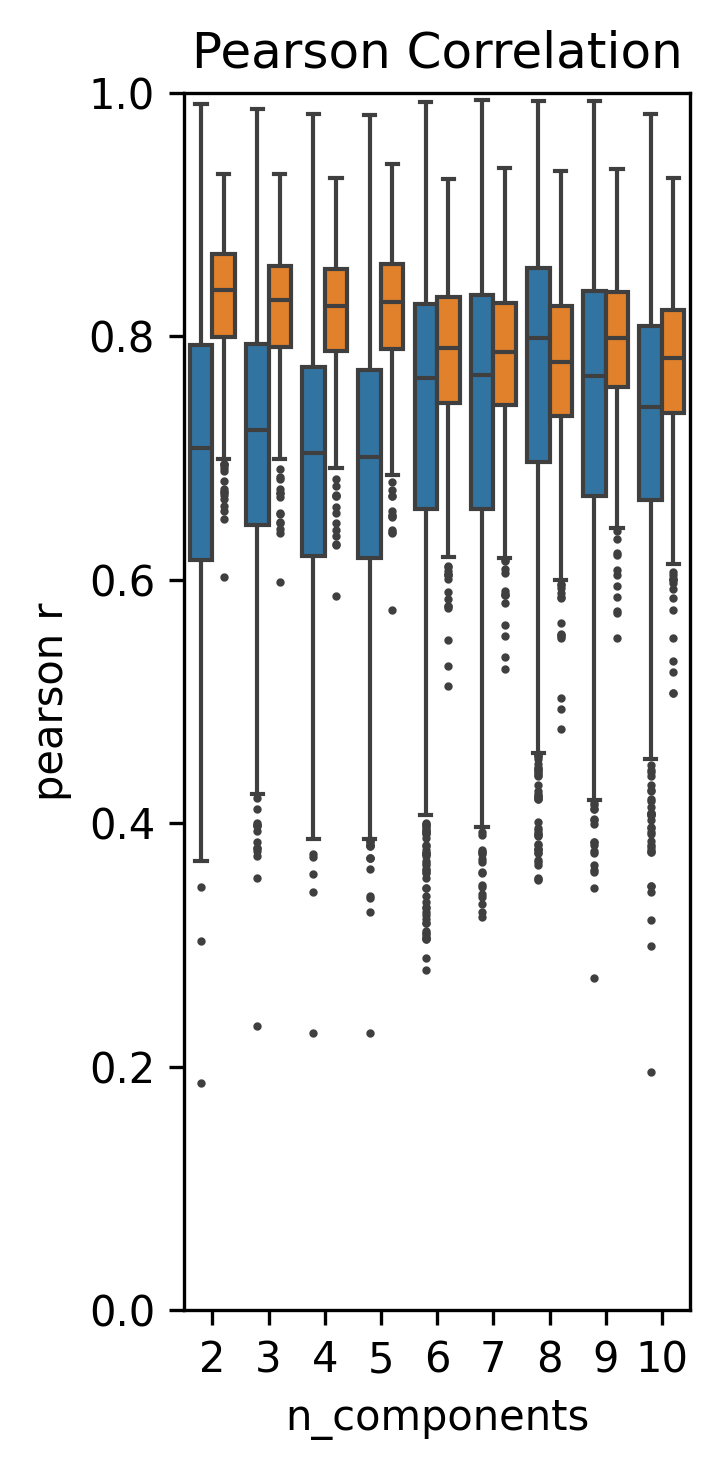

In [72]:
col_x = "n_components"
col_y = "pearson r"
source_col = "Source"

df_long = pd.concat([
    pearson_raw.melt(var_name=col_x, value_name=col_y).assign(**{source_col: "Raw"}),
    pearson_transform.melt(var_name=col_x, value_name=col_y).assign(**{source_col: "Log"})
])

plt.figure(figsize=(2.5, 5), dpi=300)
sns.boxplot(x=col_x, y=col_y, hue=source_col, data=df_long, dodge=True, legend=False, fliersize=1)
plt.ylim(0, 1)

plt.title("Pearson Correlation")


plt.tight_layout()
plt.show()

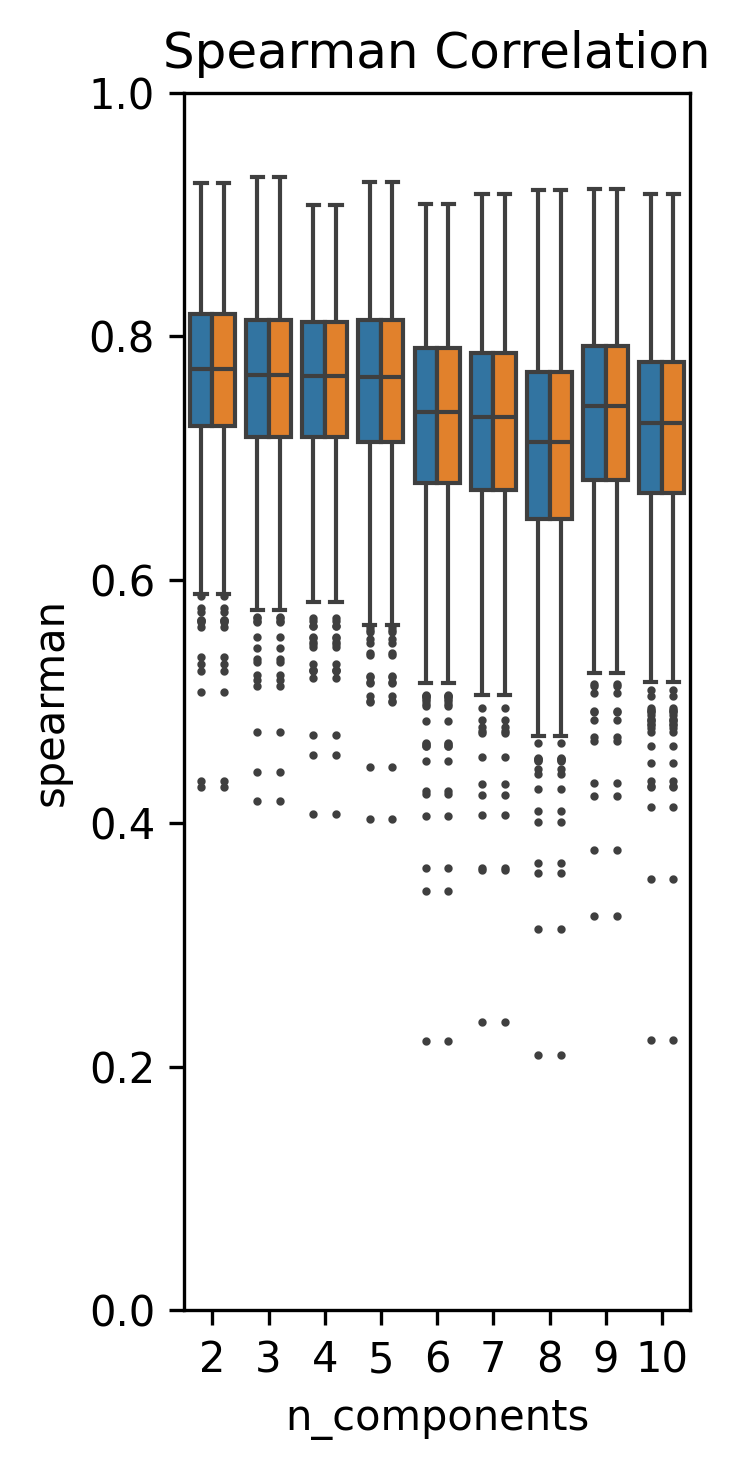

In [74]:
col_x = "n_components"
col_y = "spearman"
source_col = "Source"

df_long = pd.concat([
    spearman_raw.melt(var_name=col_x, value_name=col_y).assign(**{source_col: "Raw"}),
    spearman_transform.melt(var_name=col_x, value_name=col_y).assign(**{source_col: "Log"})
])

plt.figure(figsize=(2.5, 5), dpi=300)
sns.boxplot(x=col_x, y=col_y, hue=source_col, data=df_long, dodge=True, legend=False, fliersize=1)
plt.ylim(0, 1)

plt.title("Spearman Correlation")


plt.tight_layout()
plt.show()

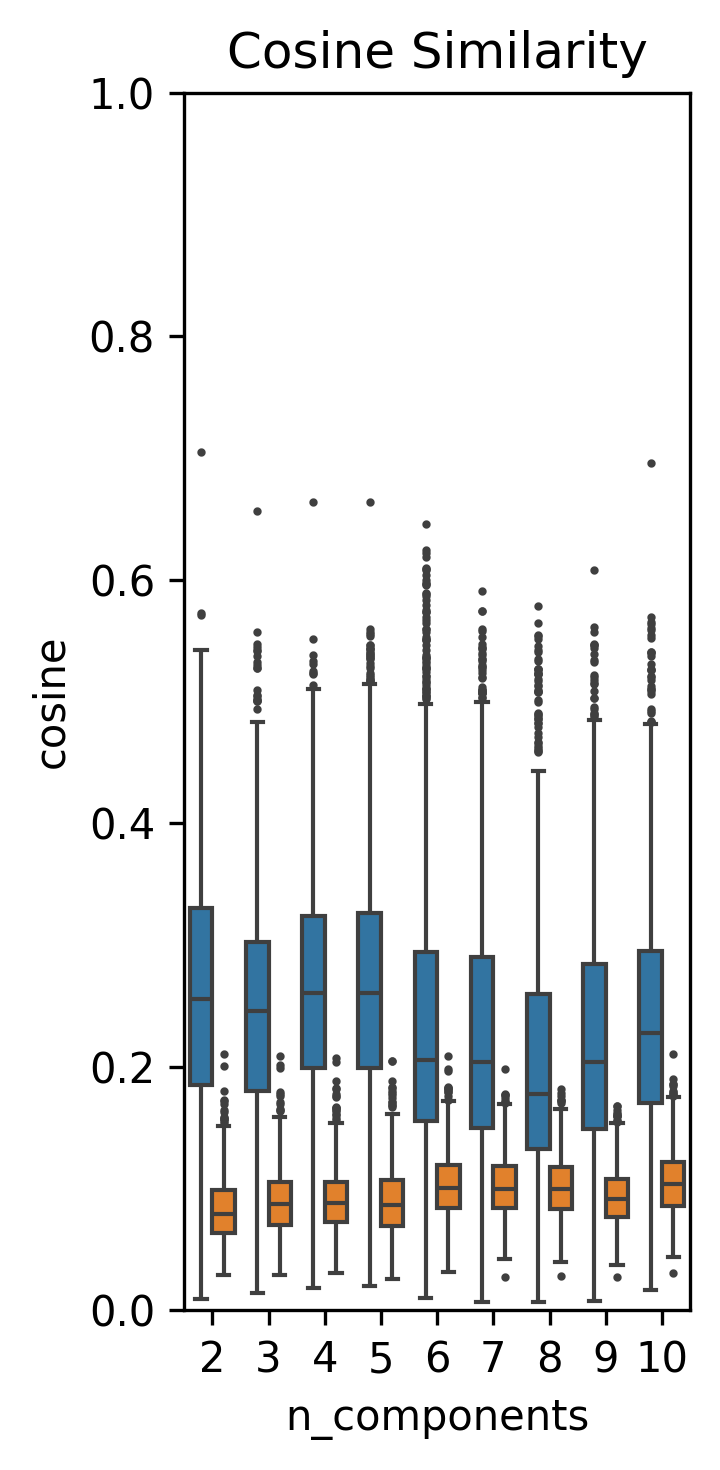

In [75]:
col_x = "n_components"
col_y = "cosine"
source_col = "Source"

df_long = pd.concat([
    cosine_raw.melt(var_name=col_x, value_name=col_y).assign(**{source_col: "Raw"}),
    cosine_transform.melt(var_name=col_x, value_name=col_y).assign(**{source_col: "Log"})
])

plt.figure(figsize=(2.5, 5), dpi=300)
sns.boxplot(x=col_x, y=col_y, hue=source_col, data=df_long, dodge=True, legend=False, fliersize=1)
plt.ylim(0, 1)

plt.title("Cosine Similarity")


plt.tight_layout()
plt.show()